In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, accuracy_score
)
from scipy.sparse import csr_matrix
import faiss


In [4]:
data= 'C:\\Users\\gidde\\Downloads\\ecommerce_customer_data_custom_ratios.csv'

In [5]:
df = pd.read_csv(data)
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1
5,13593,2023-03-07 14:17:42,Home,250,4,575,PayPal,49,1.0,James Grant,49,Female,1
6,13593,2023-04-15 03:02:33,Electronics,73,1,1896,Credit Card,49,0.0,James Grant,49,Female,1
7,13593,2021-03-27 21:23:28,Books,337,2,2937,Cash,49,0.0,James Grant,49,Female,1
8,13593,2020-05-05 20:14:00,Clothing,182,2,3363,PayPal,49,1.0,James Grant,49,Female,1
9,28805,2023-09-13 04:24:00,Electronics,394,2,1993,Credit Card,19,0.0,Jose Collier,19,Male,0


In [6]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [7]:
df.shape

(250000, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [9]:
categorical=list(df.select_dtypes(include='object').columns)
numerical=list(df.select_dtypes(include=['float64','int64']).columns)
print(f"There are {len(categorical)} Categorical columns: {categorical}")
print(f"There are {len(numerical)} Numerical columns: {numerical}")
print(f"Total number of columns :{len(numerical)+len(categorical)}")

There are 5 Categorical columns: ['Purchase Date', 'Product Category', 'Payment Method', 'Customer Name', 'Gender']
There are 8 Numerical columns: ['Customer ID', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age', 'Returns', 'Age', 'Churn']
Total number of columns :13


In [10]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Drop rows with missing critical data or impute where appropriate
ecommerce_data_cleaned = df.dropna()

Missing Values:
 Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [11]:
def clean_data(df):
    df = df.dropna(subset=[
        'Customer ID', 'Product Category', 'Total Purchase Amount',
        'Payment Method', 'Gender'
    ])
    df['Customer ID'] = df['Customer ID'].astype(str)
    df['Product Category'] = df['Product Category'].astype(str)
    df['Payment Method'] = df['Payment Method'].astype(str)
    df['Gender'] = df['Gender'].astype(str)

    if 'Returns' in df.columns:
        df['Returns'] = df['Returns'].fillna(0)

    if 'Purchase Date' in df.columns:
        df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

    df['metadata'] = df['Product Category'] + ' ' + df['Payment Method'] + ' ' + df['Gender']
    return df

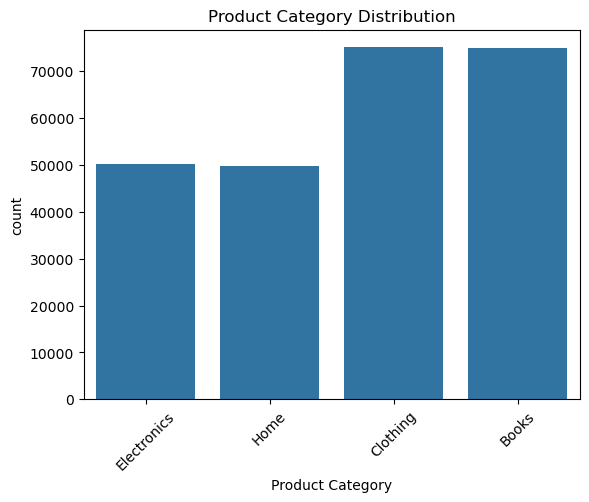

In [12]:
# Plot product categories distribution
sns.countplot(data=df, x='Product Category')
plt.title('Product Category Distribution')
plt.xticks(rotation=45)
plt.show()



C:\Users\gidde\AppData\Local\Temp\ipykernel_19892\3829141461.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Purchase Amount', ci=None)


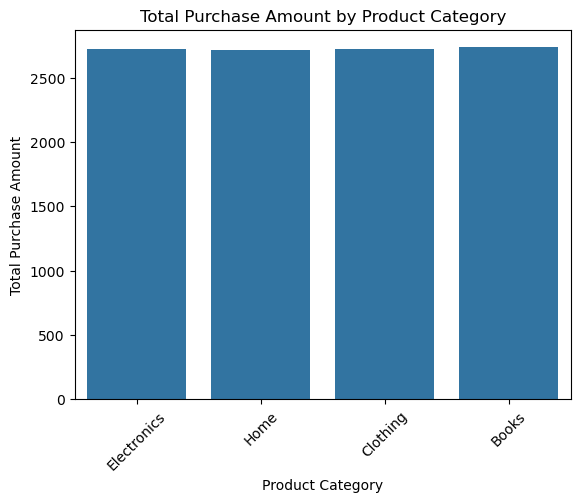

In [13]:
sns.barplot(data=df, x='Product Category', y='Total Purchase Amount', ci=None)
plt.title('Total Purchase Amount by Product Category')
plt.xticks(rotation=45)
plt.show()

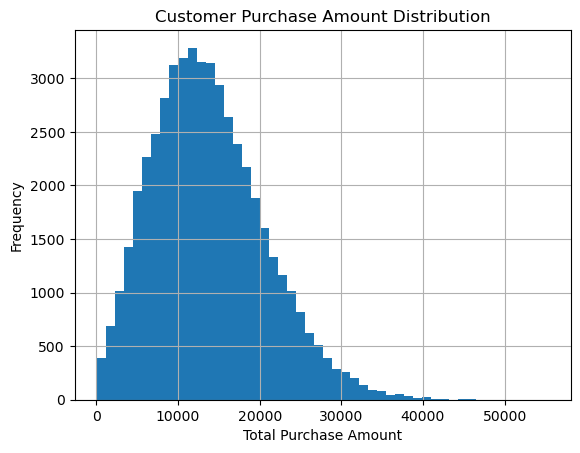

In [14]:
# Analyze user purchase patterns
df.groupby('Customer ID')['Total Purchase Amount'].sum().hist(bins=50)
plt.title('Customer Purchase Amount Distribution')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Frequency')
plt.show()

User-Based Recommender

In [15]:
def prepare_user_matrix(df):
    matrix = df.pivot_table(index='Customer ID', columns='Product Category',
                            values='Total Purchase Amount', aggfunc='sum', fill_value=0)
    sparse = csr_matrix(matrix.values)
    return matrix, sparse

In [16]:
def recommend_user_based(user_id, user_item_matrix, user_item_sparse, top_n=10):
    if user_id not in user_item_matrix.index:
        return []
    idx = user_item_matrix.index.get_loc(user_id)
    user_vec = user_item_sparse[idx]
    sim = cosine_similarity(user_vec, user_item_sparse).flatten()
    top_users = np.argsort(sim)[::-1][1:top_n + 20]
    items = user_item_matrix.iloc[top_users].sum(axis=0)
    already_bought = user_item_matrix.iloc[idx] > 0
    recs = items[~already_bought]
    return recs.sort_values(ascending=False).head(top_n)

CONTENT-BASED RECOMMENDER

In [17]:
def prepare_content_model(df):
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(df['metadata'].fillna(""))

    n_components = min(100, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components)
    reduced = svd.fit_transform(tfidf_matrix)
    reduced = reduced / np.linalg.norm(reduced, axis=1, keepdims=True)

    d = reduced.shape[1]
    quantizer = faiss.IndexFlatIP(d)
    index = faiss.IndexIVFFlat(quantizer, d, 100, faiss.METRIC_INNER_PRODUCT)
    index.train(reduced.astype('float32'))
    index.add(reduced.astype('float32'))

    return reduced, index


In [18]:
def recommend_content_faiss(idx, reduced, index, df, top_k=10):
    distances, indices = index.search(reduced[idx].reshape(1, -1).astype('float32'), top_k + 1)
    return df.iloc[indices[0][1:]]

HYBRID RECOMMENDER

In [19]:
def recommend_hybrid(user_id, sample_idx, df, user_item_matrix, user_item_sparse, reduced, index, user_weight=0.6, top_k=10):
    user_recs = recommend_user_based(user_id, user_item_matrix, user_item_sparse, top_k * 2)
    content_df = recommend_content_faiss(sample_idx, reduced, index, df, top_k * 2)
    content_scores = content_df['Product Category'].value_counts(normalize=True)

    hybrid_scores = {}
    for cat in set(user_recs.index) & set(content_scores.index):
        hybrid_scores[cat] = user_weight * user_recs[cat] + (1 - user_weight) * content_scores[cat]

    sorted_hybrid = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
    return pd.DataFrame(sorted_hybrid, columns=["Product Category", "Score"])


EVALUATION METRICS

In [20]:
def get_ground_truth_matrix(df):
    bin_matrix = df.pivot_table(index='Customer ID', columns='Product Category',
                                values='Quantity', aggfunc='sum', fill_value=0)
    return (bin_matrix > 0).astype(int)


In [21]:
def evaluate_top_k(true_matrix, rec_dict, k=5):
    y_true_all, y_pred_all = [], []

    for user_id, recs in rec_dict.items():
        if user_id not in true_matrix.index:
            continue
        user_truth = true_matrix.loc[user_id]
        actual = user_truth[user_truth == 1].index.tolist()

        y_true = [1 if cat in actual else 0 for cat in recs]
        y_pred = [1] * len(recs)

        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    return {
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "MAE": mean_absolute_error(y_true_all, y_pred_all),
        "MSE": mean_squared_error(y_true_all, y_pred_all)
    }

In [22]:
def plot_model_comparison(metric_results: dict):
    df_metrics = pd.DataFrame(metric_results).T
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    df_metrics[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=axes[0], title="Classification Metrics")
    df_metrics[['MAE']].plot(kind='bar', ax=axes[1], title="Mean Absolute Error", color='orange')
    df_metrics[['MSE']].plot(kind='bar', ax=axes[2], title="Mean Squared Error", color='red')

    for ax in axes:
        ax.set_ylabel("")
        ax.set_xlabel("")

    fig.tight_layout()
    return fig

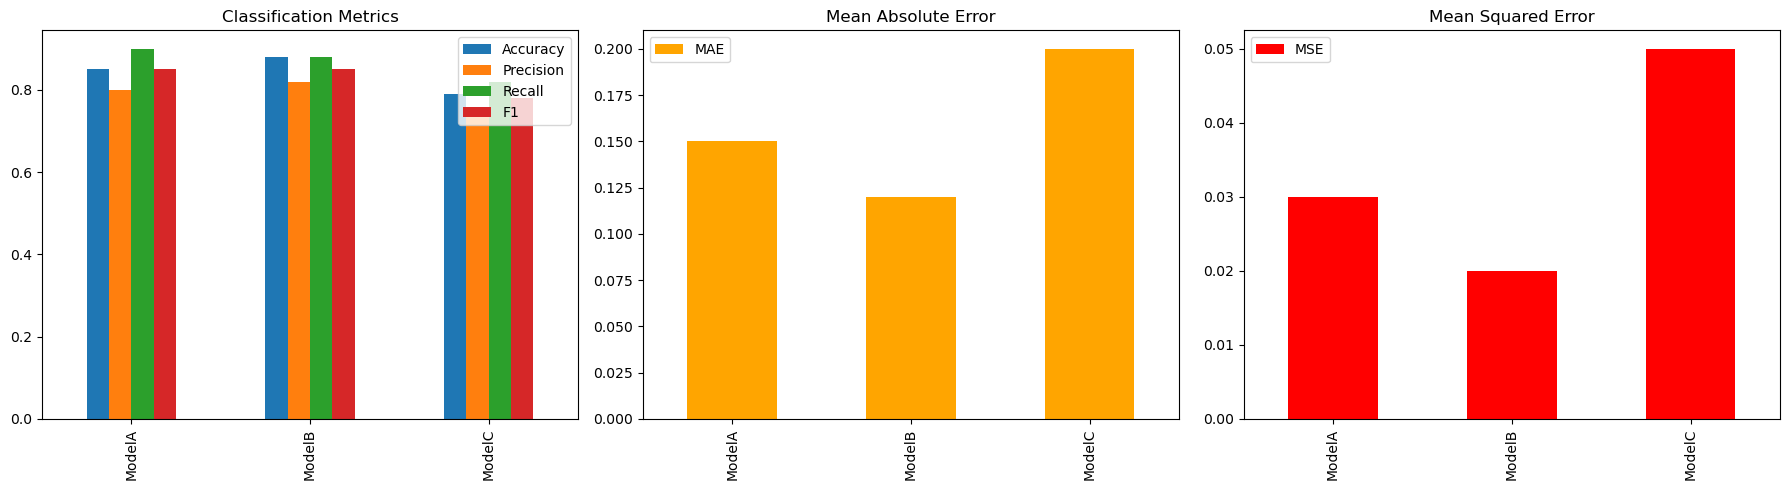

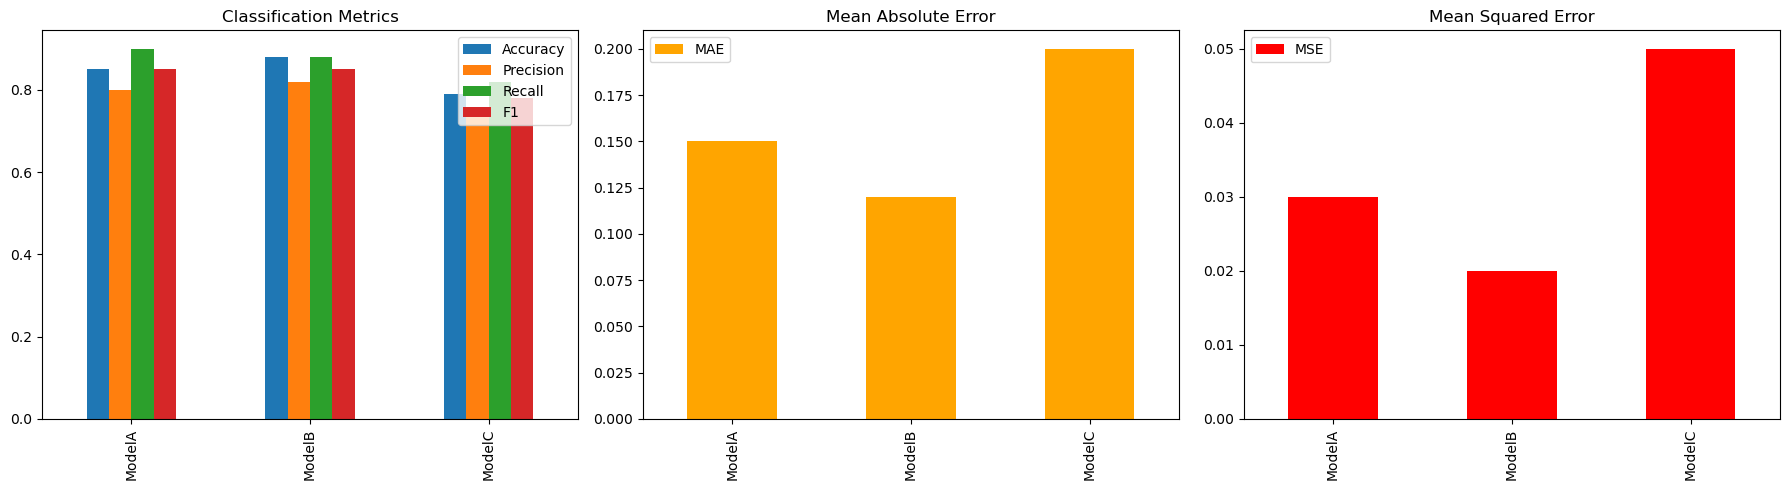

In [23]:

def plot_model_comparison(metric_results: dict):
    df_metrics = pd.DataFrame(metric_results).T
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    df_metrics[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=axes[0], title="Classification Metrics")
    df_metrics[['MAE']].plot(kind='bar', ax=axes[1], title="Mean Absolute Error", color='orange')
    df_metrics[['MSE']].plot(kind='bar', ax=axes[2], title="Mean Squared Error", color='red')

    for ax in axes:
        ax.set_ylabel("")
        ax.set_xlabel("")

    fig.tight_layout()
    # In Jupyter, returning the figure object or calling plt.show()
    # at the end of the cell will display the plot.
    # We'll explicitly call plt.show() for clarity.
    plt.show() 
    return fig

# --- Example Usage (Place this in a separate cell or below the function definition) ---
# Sample metric results (replace with your actual data)
sample_metric_results = {
    'ModelA': {
        'Accuracy': 0.85, 'Precision': 0.80, 'Recall': 0.90, 'F1': 0.85,
        'MAE': 0.15, 'MSE': 0.03
    },
    'ModelB': {
        'Accuracy': 0.88, 'Precision': 0.82, 'Recall': 0.88, 'F1': 0.85,
        'MAE': 0.12, 'MSE': 0.02
    },
    'ModelC': {
        'Accuracy': 0.79, 'Precision': 0.75, 'Recall': 0.82, 'F1': 0.78,
        'MAE': 0.20, 'MSE': 0.05
    }
}

# Call the function to plot
plot_model_comparison(sample_metric_results)

In [24]:
# Step 1: Generate user-item matrix (for user-based CF)
user_item_matrix = df.pivot_table(index='Customer ID', columns='Product Category', values='Total Purchase Amount', aggfunc='sum', fill_value=0)

from scipy.sparse import csr_matrix
user_item_sparse = csr_matrix(user_item_matrix.values)


In [25]:
# Step 2: Generate content-based model (TF-IDF + SVD + Faiss)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np
import faiss

df['metadata'] = df['Product Category'] + ' ' + df['Payment Method'] + ' ' + df['Gender']
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['metadata'].fillna(""))

n_components = min(100, tfidf_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components)
reduced_matrix = svd.fit_transform(tfidf_matrix)
reduced_matrix = reduced_matrix / np.linalg.norm(reduced_matrix, axis=1, keepdims=True)

d = reduced_matrix.shape[1]
quantizer = faiss.IndexFlatIP(d)
faiss_index = faiss.IndexIVFFlat(quantizer, d, 100, faiss.METRIC_INNER_PRODUCT)
faiss_index.train(reduced_matrix.astype('float32'))
faiss_index.add(reduced_matrix.astype('float32'))


In [26]:
import os
import pickle
import faiss

os.makedirs("models", exist_ok=True)

with open("models/user_item_matrix.pkl", "wb") as f:
    pickle.dump(user_item_matrix, f)

with open("models/user_item_sparse.pkl", "wb") as f:
    pickle.dump(user_item_sparse, f)

with open("models/reduced_matrix.pkl", "wb") as f:
    pickle.dump(reduced_matrix, f)

faiss.write_index(faiss_index, "models/faiss_index.index")
